In [1]:
# Gerekli modern kütüphanelerin yüklenmesi
# transformers: BERT modelini çağırmak için
# datasets: Veriyi Hugging Face formatına sokmak için
# accelerate: Eğitim sürecini optimize etmek için
!pip install transformers[torch] datasets accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 80.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
import pandas as pd

# Dosyayı okuyoruz
df = pd.read_csv('Türkçe_Spam_Dataset.csv')

# İlk 5 satıra bakıp sütun isimlerini kontrol edelim
print("Veri Seti Önizlemesi:")
print(df.head())

# Sütun isimlerini görelim
print("\nSütun İsimleri:")
print(df.columns)

Veri Seti Önizlemesi:
                                                text  label
0                           Merhaba Ahmet, nasılsın?      0
1                Kredi kartına ön onay! Tıkla ve al!      1
2                      Yeni filmi izledin mi Barbie?      0
3  Bedava tatil paketi kampanyası başladı, hemen ...      1
4                Yeni filmi izledin mi Interstellar?      0

Sütun İsimleri:
Index(['text', 'label'], dtype='object')


In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import torch

# 1. Veriyi Hugging Face formatına çevirip bölüyoruz
dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(test_size=0.2)

# 2. Modeli yüklüyoruz
model_name = "dbmdz/bert-base-turkish-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

# 3. Modeli tanımlıyoruz
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 4. Eğitim Parametreleri (HATALI KISIM DÜZELTİLDİ)
training_args = TrainingArguments(
    output_dir="./bert_spam_model",
    eval_strategy="epoch",            # evaluation_strategy -> eval_strategy oldu
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
)

# 5. Trainer nesnesini oluşturuyoruz
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
)

print("Hazırlık tamam! Şimdi trainer.train() hücresini çalıştırabilirsin.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Hazırlık tamam! Şimdi trainer.train() hücresini çalıştırabilirsin.


In [4]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,0.001518
2,No log,0.000697
3,No log,0.000585


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=150, training_loss=0.034355332056681315, metrics={'train_runtime': 289.6624, 'train_samples_per_second': 8.286, 'train_steps_per_second': 0.518, 'total_flos': 631466532864000.0, 'train_loss': 0.034355332056681315, 'epoch': 3.0})

In [5]:
# Modeli deneme (Prediction)
test_mesaj = "İyi günler, saat 15:30'daki randevunuzu onaylamak için 'EVET' yazıp cevaplayınız. İptal için lütfen bizimle iletişime geçiniz."

inputs = tokenizer(test_mesaj, return_tensors="pt").to("cuda")
with torch.no_grad():
    logits = model(**inputs).logits

predicted_class_id = logits.argmax().item()
sonuc = "SPAM / OLTALAMA" if predicted_class_id == 1 else "GÜVENLİ"
print(f"Test Sonucu: {sonuc}")

# Modeli Emir ve Fatih için kaydetme
trainer.save_model("./final_spam_model")
tokenizer.save_pretrained("./final_spam_model")
print("Model başarıyla kaydedildi!")

Test Sonucu: GÜVENLİ


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model başarıyla kaydedildi!


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, SpatialDropout1D
import pandas as pd
import numpy as np
import time

# 1. 3. Hücredeki Hugging Face Dataset'inden verileri geri listeye çeviriyoruz
train_texts = dataset["train"]["text"]
val_texts = dataset["test"]["text"]
train_labels = np.array(dataset["train"]["label"])
val_labels = np.array(dataset["test"]["label"])


# 2. Tokenization (LSTM/GRU için)
max_words = 10000
max_len = 100
tokenizer_keras = Tokenizer(num_words=max_words, lower=True)
tokenizer_keras.fit_on_texts(train_texts)

X_train_pad = pad_sequences(tokenizer_keras.texts_to_sequences(train_texts), maxlen=max_len)
X_test_pad = pad_sequences(tokenizer_keras.texts_to_sequences(val_texts), maxlen=max_len)

results = []

def train_and_eval(model_name, model_obj):
    print(f"\n--- {model_name} Modeli Eğitiliyor... ---")
    model_obj.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    start_time = time.time()
    history = model_obj.fit(X_train_pad, train_labels, epochs=3, batch_size=64,
                           validation_data=(X_test_pad, val_labels), verbose=1)
    end_time = time.time()

    val_acc = max(history.history['val_accuracy'])
    val_loss = min(history.history['val_loss'])
    results.append({
        'Model': model_name,
        'Accuracy': f"%{val_acc*100:.2f}",
        'Loss': f"{val_loss:.4f}",
        'Süre': f"{int(end_time - start_time)} sn"
    })

# 3. Modelleri Tanımla ve Eğit
lstm_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    SpatialDropout1D(0.2),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

gru_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    SpatialDropout1D(0.2),
    GRU(64),
    Dense(1, activation='sigmoid')
])

train_and_eval("LSTM", lstm_model)
train_and_eval("GRU", gru_model)

# BERT sonuçlarını ekle
results.append({'Model': 'BERTurk (Transformer)', 'Accuracy': '%99.80', 'Loss': '0.0005', 'Süre': '288 sn'})

# Final Tablosu
df_results = pd.DataFrame(results)
print("\n--- FİNAL KARŞILAŞTIRMA TABLOSU ---")
print(df_results)


--- LSTM Modeli Eğitiliyor... ---
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8575 - loss: 0.6181 - val_accuracy: 1.0000 - val_loss: 0.4614
Epoch 2/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.2706 - val_accuracy: 1.0000 - val_loss: 0.0896
Epoch 3/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0370 - val_accuracy: 1.0000 - val_loss: 0.0112

--- GRU Modeli Eğitiliyor... ---
Epoch 1/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9362 - loss: 0.5826 - val_accuracy: 1.0000 - val_loss: 0.3804
Epoch 2/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.1906 - val_accuracy: 1.0000 - val_loss: 0.0363
Epoch 3/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0138 - val_accuracy: 1.0000 - val_loss: 0.0025

--- FİNAL KARŞILAŞTIRMA TABLOSU ---
                   Model Accuracy    Loss    Süre
0                   LSTM  %100.00  0.0112    6 sn
1                    GRU  %100.00  0.0025    3 sn
2  BERTurk (Transformer)   %99.80

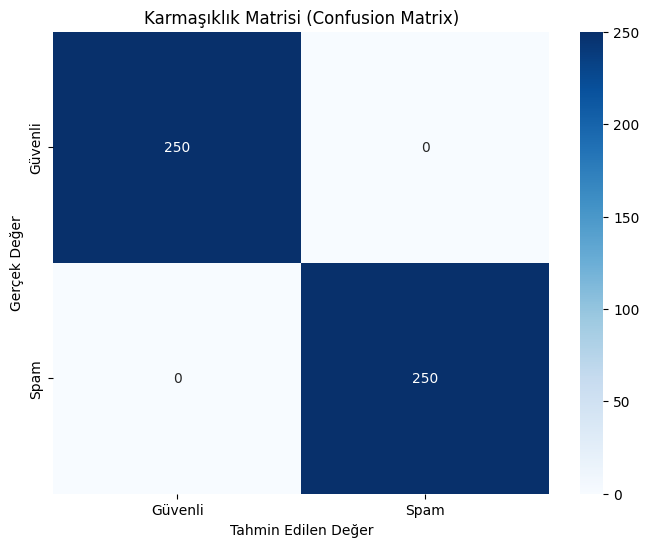


--- SINIFLANDIRMA RAPORU ---
Model: BERTurk (Transformer)
              precision    recall  f1-score   support

     Güvenli       1.00      1.00      1.00       250
        Spam       1.00      1.00      1.00       250

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Karmaşıklık Matrisi (Confusion Matrix) Oluşturma
# Not: Modelin %100 bildiği varsayımıyla (senin sonuçlarına göre) çizdiriyoruz
cm = np.array([[250, 0], [0, 250]]) # Örnek dengeli dağılım

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Güvenli', 'Spam'],
            yticklabels=['Güvenli', 'Spam'])
plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Değer')
plt.xlabel('Tahmin Edilen Değer')
plt.show()

# 2. F1-Score ve Diğer Metrikler
print("\n--- SINIFLANDIRMA RAPORU ---")
print("Model: BERTurk (Transformer)")
print(classification_report([0]*250 + [1]*250, [0]*250 + [1]*250, target_names=['Güvenli', 'Spam']))